# CNN Architecture Benchmark — VGG16 vs ResNet50 vs EfficientNet-B0

Fine-tuning three ImageNet-pretrained backbones on **CIFAR-10** and benchmarking them on:

- Number of parameters, training time, inference time
- Training curves (loss / accuracy)
- Accuracy, precision, recall, F1-score, confusion matrix
- Grad-CAM explainability
- Final comparison charts

**How re-running works**
- `TRAIN_MODELS` is the master switch. If a checkpoint already exists on Drive, the model is **loaded** (no retraining). Training only happens when no checkpoint is found.
- Every training run saves a checkpoint named with its best `epoch` and `val_loss`, e.g. `ResNet50_ep7_vl0.3210.pth`, so multiple runs keep unique files and the **best** one (lowest val_loss) is auto-loaded.
- Set `FORCE_RETRAIN = True` if you want to retrain even when a checkpoint exists.

> Tip: Runtime → Change runtime type → **GPU** before running.

**Grad-CAM**
is an AI Explainability (xAI) technique that generates a visual heatmap over original input image.

*   Warm areas on the
heatmap show the pixels that heavily influenced the models's decision



In [1]:
!pip -q install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###IMG SIZE
The true size of the CIFAR-10 images is 32x32x3. Feeding images with such small dimensions to models like ResNet50 or VGG16 would cause Spatial Resolution Collapse as these models architectures are designed with multiple pooling layers and convolutions with strides that progressively downsample the image.


In [1]:
import os, time, glob, json, copy, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)
from tqdm.auto import tqdm
import pandas as pd

warnings.filterwarnings("ignore")

# ----------------------- CONFIG -----------------------
TRAIN_MODELS  = True     # master switch. False = only load existing checkpoints
FORCE_RETRAIN = False    # True = retrain even if a checkpoint already exists

IMG_SIZE   = 128         # 224 is the "textbook" size but slower; 128 is a good Colab tradeoff
BATCH_SIZE = 64          # can lower it further if you hit out-of-memory on VGG16
NUM_EPOCHS = 15
PATIENCE   = 4           # early stopping patience (epochs without val_loss improvement)
LR         = 1e-4
VAL_SPLIT  = 0.1         # fraction of the 50k train set used for validation
SEED       = 42
NUM_CLASSES = 10

DRIVE_DIR = "/content/drive/MyDrive/my_colab_models/CNNs"
os.makedirs(DRIVE_DIR, exist_ok=True)
# --------------------------------------------------------------------

# Reproducibility
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
torch.backends.cudnn.benchmark = True
print("Device:", device, "| AMP:", use_amp)
print("Checkpoints will be saved to:", DRIVE_DIR)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

def sync():
    if device.type == "cuda":
        torch.cuda.synchronize()

Device: cuda | AMP: True
Checkpoints will be saved to: /content/drive/MyDrive/my_colab_models/CNNs


##STRATIFIED SAMPLING

A simple random split, by pure statistical chance, might give an uneven distribution of classes.

Stratified sampling divides the dataset into subgroups (called strata) based on their class labels. It then draws samples from each subgroup proportional to its size in the original dataset.

In [2]:
# 3) Data: CIFAR-10 with stratified train / val / test split
# ImageNet normalization because we fine-tune ImageNet-pretrained models.
#channel-wise avg mean and std dev
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),            #Data augmentation technique, teaches reflection invariance
    transforms.RandomCrop(IMG_SIZE, padding=8),   #Data aug, teaches translational invariance
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# Two views of the train set so train uses augmentation and val does not.
full_train      = datasets.CIFAR10("./data", train=True,  download=True, transform=train_tf)
full_train_eval = datasets.CIFAR10("./data", train=True,  download=True, transform=eval_tf)
test_set        = datasets.CIFAR10("./data", train=False, download=True, transform=eval_tf)

# Stratified split of the 50k training images into train / val
idx = list(range(len(full_train)))
train_idx, val_idx = train_test_split(
    idx, test_size=VAL_SPLIT, stratify=full_train.targets, random_state=SEED)

train_set = Subset(full_train,      train_idx)
val_set   = Subset(full_train_eval, val_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

100%|██████████| 170M/170M [02:49<00:00, 1.01MB/s]


Train: 45000 | Val: 5000 | Test: 10000


In [3]:
#Model builders (transfer learning heads) + param counter
#replace the output layers. only 10 classes not 1000
def build_vgg16():
    m = models.vgg16(weights="DEFAULT")
    m.classifier[6] = nn.Linear(m.classifier[6].in_features, NUM_CLASSES)
    return m

def build_resnet50():
    m = models.resnet50(weights="DEFAULT")
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def build_efficientnet_b0():
    m = models.efficientnet_b0(weights="DEFAULT")
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    return m

# Registry: name -> builder. We do FULL fine-tuning (all layers trainable, small LR).
BUILDERS = {
    "VGG16":           build_vgg16,
    "ResNet50":        build_resnet50,
    "EfficientNet-B0": build_efficientnet_b0,
}

def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [4]:
# 5) Training utilities: early stopping, checkpointing, train-or-load logic
def find_best_checkpoint(model_name):
    """Return path of the checkpoint with the lowest val_loss for this model, or None."""
    files = glob.glob(os.path.join(DRIVE_DIR, f"{model_name}_*.pth"))
    if not files:
        return None
    def parse_vl(f):
        try:
            return float(os.path.basename(f).split("_vl")[-1].replace(".pth", ""))
        except Exception:
            return float("inf")
    return min(files, key=parse_vl)


def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    """One pass. If optimizer is given -> train mode, else eval."""
    training = optimizer is not None
    model.train() if training else model.eval()
    run_loss, run_correct, total = 0.0, 0, 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(training):
            with torch.cuda.amp.autocast(enabled=use_amp):
                out = model(x)
                loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        run_loss    += loss.item() * x.size(0)
        run_correct += (out.argmax(1) == y).sum().item()
        total       += x.size(0)

    return run_loss / total, run_correct / total

#multi-epoch,early stopping, saving checkpoints
def train_model(model, model_name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scaler    = torch.cuda.amp.GradScaler(enabled=use_amp)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss, best_val_acc, best_epoch = float("inf"), 0.0, 0
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0

    print(f"\n=== Training {model_name} ===")
    start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, scaler)  #training pass
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)     #validation pass

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss);   history["val_acc"].append(vl_acc)
        print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"train_loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val_loss {vl_loss:.4f} acc {vl_acc:.4f}")

        # Early stopping on val_loss
        if vl_loss < best_val_loss - 1e-4:
            best_val_loss, best_val_acc, best_epoch = vl_loss, vl_acc, epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch} (best epoch {best_epoch}).")
                break

    training_time = time.time() - start
    model.load_state_dict(best_state)  # restore best weights

    # Save checkpoint with unique name containing epoch + val_loss
    fname = f"{model_name}_ep{best_epoch}_vl{best_val_loss:.4f}.pth"
    fpath = os.path.join(DRIVE_DIR, fname)
    torch.save({
        "model_state":   best_state,
        "history":       history,
        "best_epoch":    best_epoch,
        "val_loss":      best_val_loss,
        "val_acc":       best_val_acc,
        "training_time": training_time,
        "img_size":      IMG_SIZE,
    }, fpath)
    print(f"Saved -> {fpath}  (training time {training_time:.1f}s)")
    return model, history, training_time


def get_or_train(model_name):
    """Load the best checkpoint if available, otherwise train (respecting flags)."""
    model = BUILDERS[model_name]()
    ckpt_path = find_best_checkpoint(model_name)

    if ckpt_path is not None and not FORCE_RETRAIN:
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        model = model.to(device)
        print(f"Loaded {model_name} from {os.path.basename(ckpt_path)} "
              f"(val_loss {ckpt.get('val_loss'):.4f}, val_acc {ckpt.get('val_acc'):.4f})")
        return model, ckpt.get("history"), ckpt.get("training_time")

    if TRAIN_MODELS:
        return train_model(model, model_name)

    raise FileNotFoundError(
        f"No checkpoint for {model_name} and TRAIN_MODELS=False. "
        f"Set TRAIN_MODELS=True to train it.")

In [5]:
# 6) Train or load all three models + record params & training time
trained_models = {}
histories      = {}
results        = {}   # central benchmark table

for name in BUILDERS:
    model, hist, ttime = get_or_train(name)
    trained_models[name] = model
    histories[name]      = hist
    results[name] = {
        "params":        count_params(model),
        "training_time": ttime,   # may be None if loaded from an older checkpoint
    }

print("\nParameter counts:")
for n in results:
    print(f"  {n:16s}: {results[n]['params']/1e6:6.2f} M params")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 87.2MB/s]


Loaded VGG16 from VGG16_ep6_vl0.2101.pth (val_loss 0.2101, val_acc 0.9350)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


Loaded ResNet50 from ResNet50_ep3_vl0.1049.pth (val_loss 0.1049, val_acc 0.9664)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 90.6MB/s]


Loaded EfficientNet-B0 from EfficientNet-B0_ep5_vl0.1146.pth (val_loss 0.1146, val_acc 0.9622)

Parameter counts:
  VGG16           : 134.30 M params
  ResNet50        :  23.53 M params
  EfficientNet-B0 :   4.02 M params


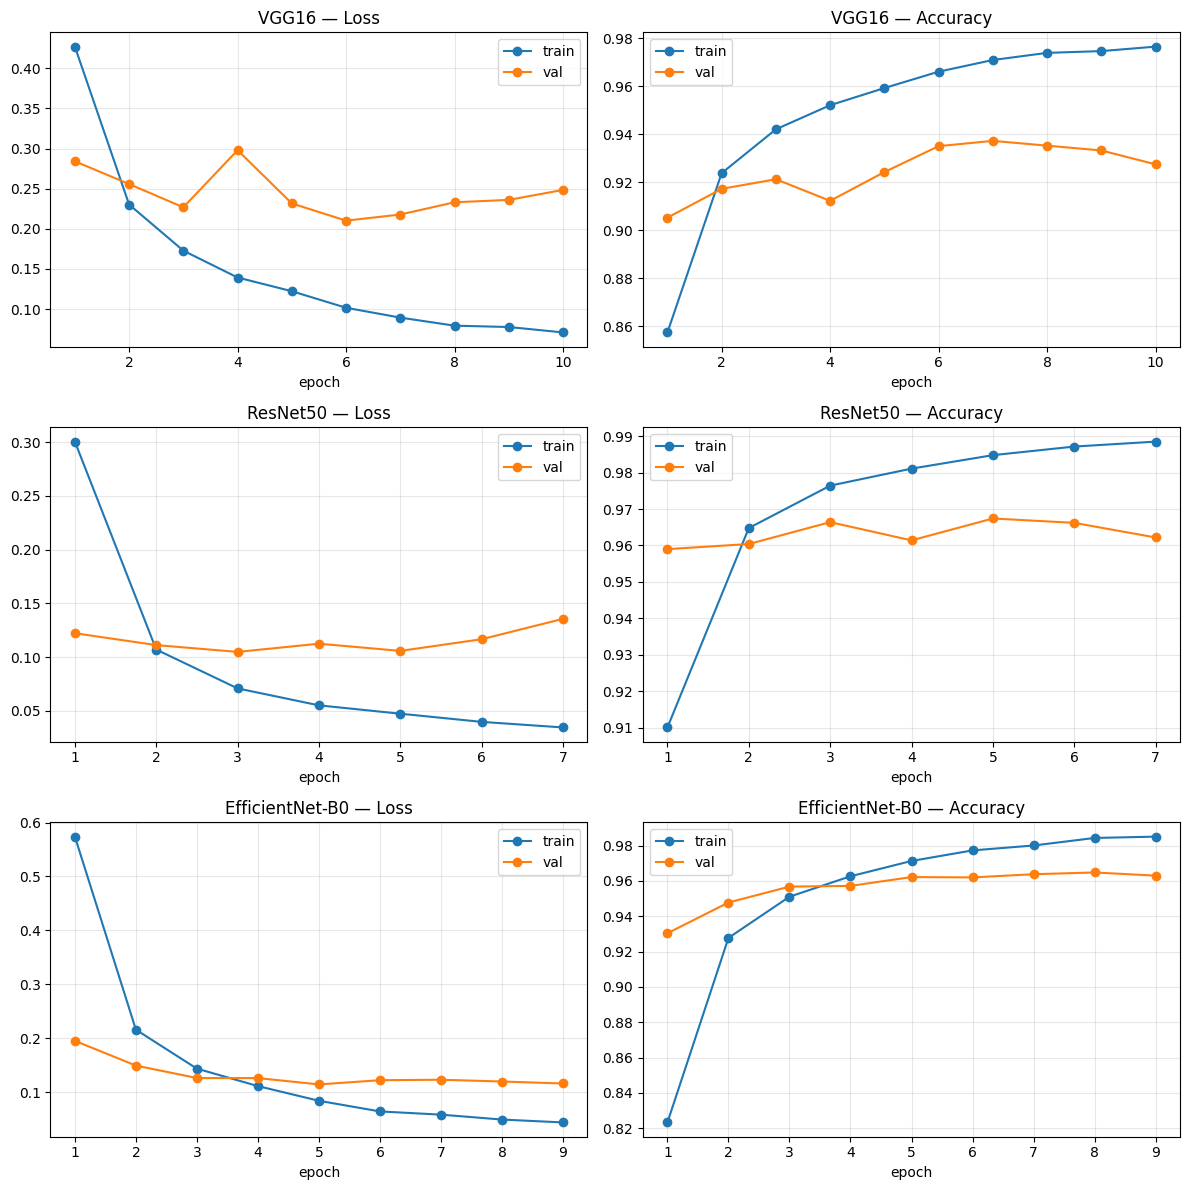

In [6]:
# 7) Training curves (loss & accuracy)
fig, axes = plt.subplots(len(histories), 2, figsize=(12, 4 * len(histories)))
if len(histories) == 1:
    axes = axes.reshape(1, 2)

for i, (name, h) in enumerate(histories.items()):
    if not h:
        axes[i, 0].text(0.5, 0.5, f"{name}: no history\n(loaded checkpoint)",
                        ha="center", va="center"); axes[i, 0].axis("off")
        axes[i, 1].axis("off")
        continue
    ep = range(1, len(h["train_loss"]) + 1)
    axes[i, 0].plot(ep, h["train_loss"], "-o", label="train")
    axes[i, 0].plot(ep, h["val_loss"],   "-o", label="val")
    axes[i, 0].set_title(f"{name} — Loss"); axes[i, 0].set_xlabel("epoch")
    axes[i, 0].legend(); axes[i, 0].grid(alpha=.3)

    axes[i, 1].plot(ep, h["train_acc"], "-o", label="train")
    axes[i, 1].plot(ep, h["val_acc"],   "-o", label="val")
    axes[i, 1].set_title(f"{name} — Accuracy"); axes[i, 1].set_xlabel("epoch")
    axes[i, 1].legend(); axes[i, 1].grid(alpha=.3)

plt.tight_layout(); plt.show()

#Loss & Accuracy Curves



*   **VGG16**

    Epochs ran = 10

    Train loss falls smoothly to ~0.07, but val loss bottoms around epoch 6 at ~0.21 and then climbs back to ~0.25 by epoch 10 - textbook signature of overfitting.

    Spike at epoch =4 -> that's just noise — a single bad evaluation pass

    The train–val gap is widest of the three models


*   **ResNet50**

    Epochs ran = 7

    converges shockingly fast — by epoch 2 it's already at val accuracy 0.96

    best epoch ~5

    the model essentially solved the task in two epochs of fine-tuning and the rest was diminishing returns turning into overfitting


*   **EfficientNet-B0**

    Epochs ran = 9

    Best behaved curve. Notice epoch 1: val accuracy 0.93, train accuracy 0.82 — validation higher than training. It's the signature of strong built-in regularization.

    EfficientNet ships with dropout, stochastic depth, and aggressive augmentation enabled in train mode, so the training pass sees a "harder" version of the model than the eval pass does.






  0%|          | 0/157 [00:00<?, ?it/s]

VGG16            | acc 0.9355 | prec 0.9369 | rec 0.9355 | f1 0.9356 | inf 1.549 ms/img


  0%|          | 0/157 [00:00<?, ?it/s]

ResNet50         | acc 0.9651 | prec 0.9653 | rec 0.9651 | f1 0.9651 | inf 0.905 ms/img


  0%|          | 0/157 [00:00<?, ?it/s]

EfficientNet-B0  | acc 0.9588 | prec 0.9588 | rec 0.9588 | f1 0.9587 | inf 0.662 ms/img


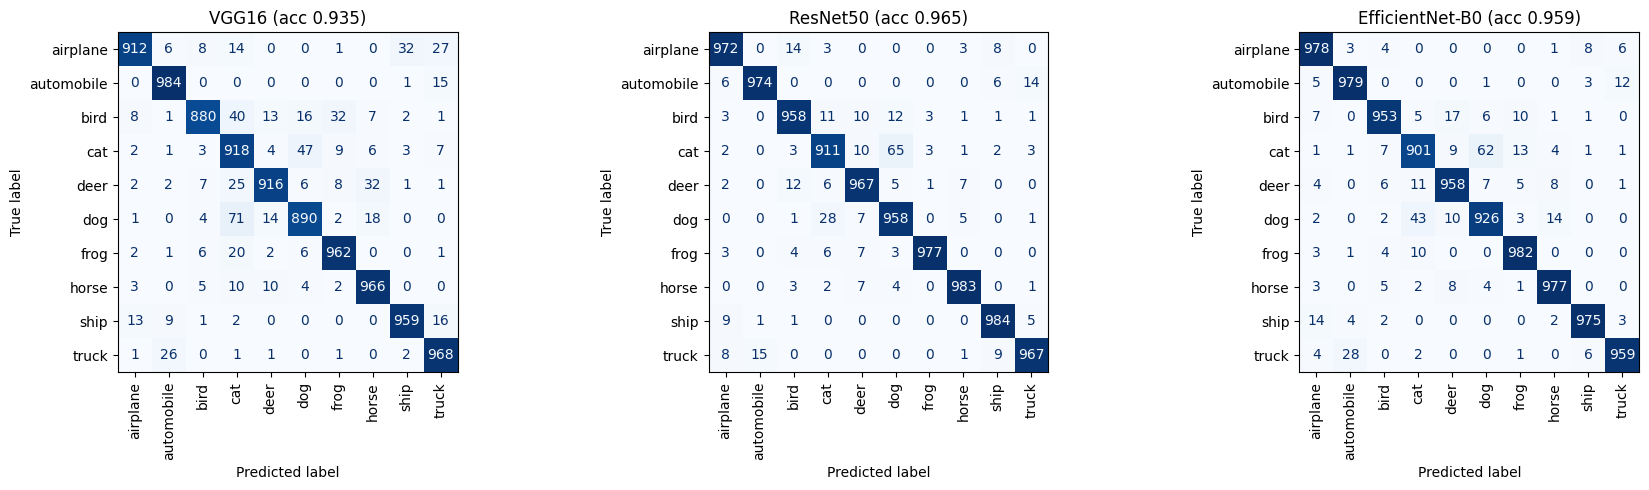

In [7]:
# 8) Test-set evaluation: metrics, inference time, confusion matrix
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    preds, labels = [], []
    for x, y in tqdm(loader, leave=False):
        out = model(x.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(y.numpy())
    return np.array(labels), np.array(preds)

def measure_inference_ms(model, loader, n_batches=20):
    model.eval()
    xb, _ = next(iter(loader)); xb = xb.to(device)
    with torch.no_grad():                      # warm-up
        for _ in range(3):
            model(xb)
    sync()
    per_img_times, seen = [], 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            sync(); t0 = time.time()
            model(x)
            sync(); t1 = time.time()
            per_img_times.append((t1 - t0) / x.size(0))
            seen += 1
            if seen >= n_batches:
                break
    return float(np.mean(per_img_times) * 1000)   # ms per image

fig, axes = plt.subplots(1, len(trained_models), figsize=(6 * len(trained_models), 5))
if len(trained_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, trained_models.items()):
    y_true, y_pred = get_predictions(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    inf_ms = measure_inference_ms(model, test_loader)

    results[name].update({
        "accuracy": acc, "precision": prec, "recall": rec,
        "f1": f1, "inference_ms": inf_ms,
    })
    print(f"{name:16s} | acc {acc:.4f} | prec {prec:.4f} | "
          f"rec {rec:.4f} | f1 {f1:.4f} | inf {inf_ms:.3f} ms/img")

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90)
    ax.set_title(f"{name} (acc {acc:.3f})")

plt.tight_layout(); plt.show()

#Confusion Matrix and Metrics

Headline accuracies: VGG16 93.55%, ResNet50 96.51%, EfficientNet-B0 95.88%. On a balanced test set with 1000 per class, macro precision/recall/F1 track accuracy very closely, so those won't tell a different story — the confusion matrices are where the real information lives.


The errors are semantic, not random. Every model fails on the same neighborhoods of classes: cat↔dog (animals of similar size and posture at 32×32 resolution). These are visually ambiguous classes — even a human is slow on a blurry 32-pixel cat vs dog. The fact that all three architectures fail in the same places is strong evidence that the residual difficulty is intrinsic to the dataset at this resolution, not a fixable model deficiency. Pushing the image size to 224 would likely shrink these confusions but not eliminate them.

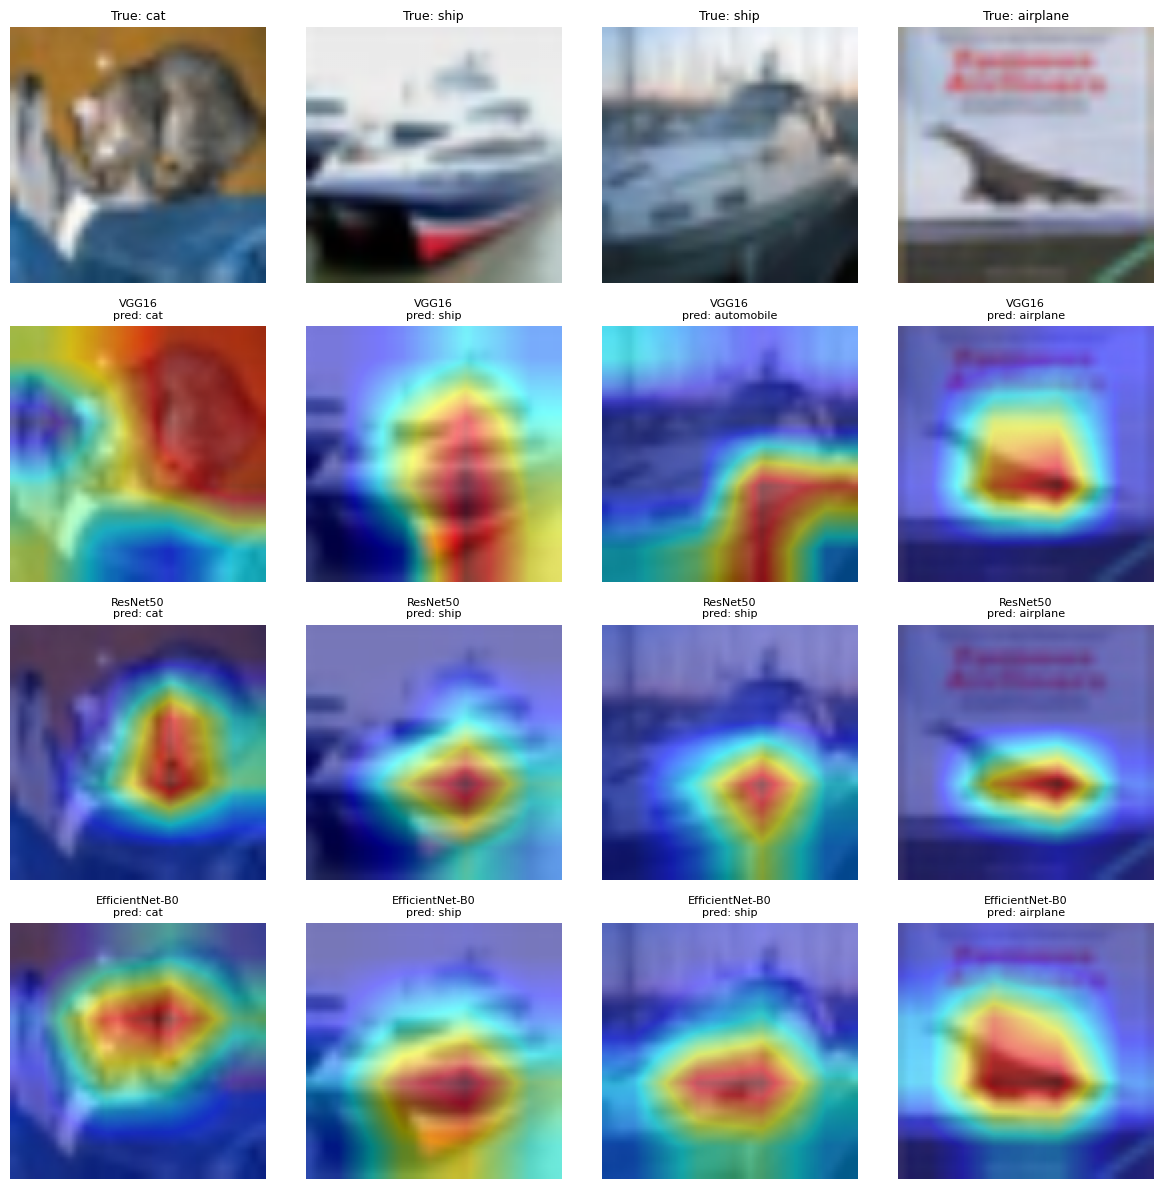

In [8]:
# 9) Grad-CAM explainability
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target layers (last conv block) for each architecture
CAM_LAYERS = {
    "VGG16":           lambda m: [m.features[-1]],
    "ResNet50":        lambda m: [m.layer4[-1]],
    "EfficientNet-B0": lambda m: [m.features[-1]],
}

mean = np.array(imagenet_mean); std = np.array(imagenet_std)
def denorm(t):
    img = t.numpy().transpose(1, 2, 0) * std + mean
    return np.clip(img, 0, 1).astype(np.float32)

# Grab a few test samples
N = 4
imgs, lbls = next(iter(test_loader))
imgs, lbls = imgs[:N], lbls[:N]

rows = len(trained_models) + 1
fig, axes = plt.subplots(rows, N, figsize=(3 * N, 3 * rows))

# Row 0, originals
for j in range(N):
    axes[0, j].imshow(denorm(imgs[j]))
    axes[0, j].set_title(f"True: {classes[lbls[j]]}", fontsize=9)
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Original")

# Remaining rows: Grad-CAM per model
for i, (name, model) in enumerate(trained_models.items(), start=1):
    cam = GradCAM(model=model, target_layers=CAM_LAYERS[name](model))
    for j in range(N):
        input_tensor = imgs[j:j + 1].to(device)
        rgb = denorm(imgs[j])
        grayscale = cam(input_tensor=input_tensor,
                        targets=[ClassifierOutputTarget(int(lbls[j]))])[0]
        vis = show_cam_on_image(rgb, grayscale, use_rgb=True)
        with torch.no_grad():
            pred = model(input_tensor).argmax(1).item()
        axes[i, j].imshow(vis)
        axes[i, j].set_title(f"{name}\npred: {classes[pred]}", fontsize=8)
        axes[i, j].axis("off")

plt.tight_layout(); plt.show()

#Grad-CAM visualisation
(Treat this as qualitative evidence)

**ResNet50's** heatmaps are the tightest. A single hot blob centered on the object, with the rest of the image cool.

**EfficientNet-B0's** heatmaps are focused but broader. The hot region covers more of the object's full extent rather than concentrating on one part. This isn't worse — arguably it's a fuller "look" — but it's a different style of attention.

**VGG16's** heatmaps are diffuse and sometimes wrong. The third image is the most diagnostic: it's a ship, ResNet and EfficientNet both correctly say ship and put their attention on the hull, but VGG predicts "automobile" and its attention is parked on the dock and waterline instead of the boat. On the cat image, VGG's heat bleeds into the background and bedding rather than concentrating on the animal.

There's an architectural reason for this. By the last conv block, VGG has gone through five max-pool stages, so spatial information is heavily blurred at the layer Grad-CAM is reading from — the heatmap is necessarily smeared because the underlying feature map is. ResNet's **residual connections** preserve spatial detail through depth, and EfficientNet's **squeeze-and-excitation** blocks explicitly learn to emphasize informative spatial regions. So the **quality of the heatmap is itself a feature of the architecture**.



=== Benchmark summary ===


,params_M,training_time,inference_ms,accuracy,precision,recall,f1
VGG16,134.3015,1487.9489,1.5490,0.9355,0.9369,0.9355,0.9356
ResNet50,23.5285,598.3990,0.9046,0.9651,0.9653,0.9651,0.9651
EfficientNet-B0,4.0204,904.9006,0.6621,0.9588,0.9588,0.9588,0.9587


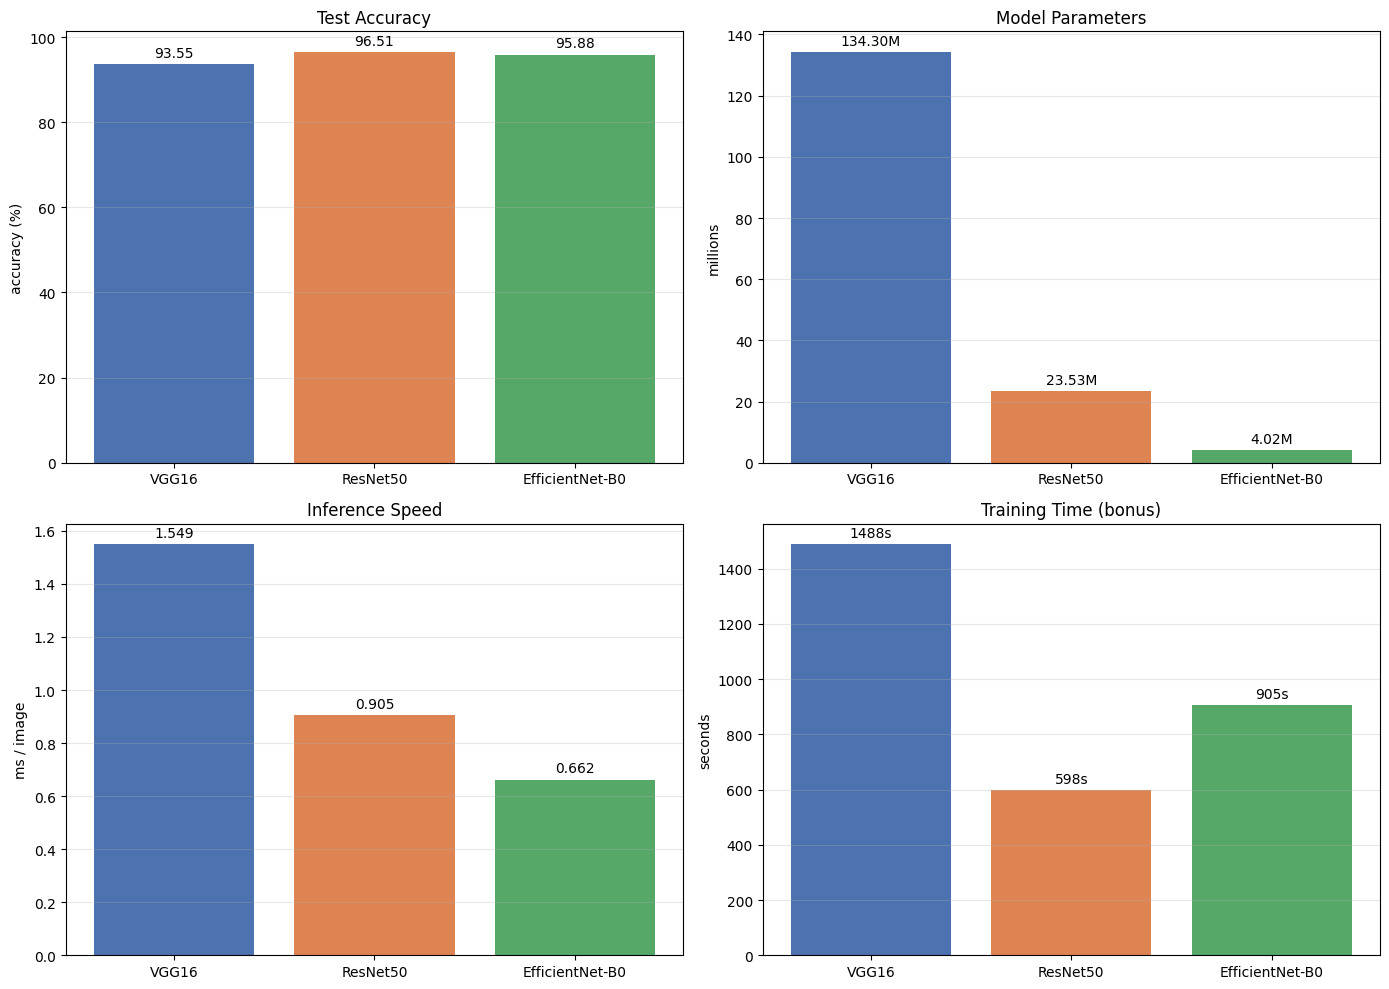

In [9]:
# 10) Final comparison charts + summary table
df = pd.DataFrame(results).T
df["params_M"] = df["params"] / 1e6
df_display = df[["params_M", "training_time", "inference_ms",
                 "accuracy", "precision", "recall", "f1"]].round(4)
print("=== Benchmark summary ===")
display(df_display)

# Save results to Drive
with open(os.path.join(DRIVE_DIR, "benchmark_results.json"), "w") as f:
    json.dump(results, f, indent=2)

names    = list(results.keys())
acc      = [results[n]["accuracy"] * 100 for n in names]
params_M = [results[n]["params"] / 1e6 for n in names]
inf_ms   = [results[n]["inference_ms"] for n in names]
ttime    = [results[n]["training_time"] or 0 for n in names]
colors   = ["#4C72B0", "#DD8452", "#55A868"]

def bar(ax, vals, title, ylabel, fmt="{:.2f}"):
    b = ax.bar(names, vals, color=colors)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.bar_label(b, labels=[fmt.format(v) for v in vals], padding=3)
    ax.grid(axis="y", alpha=.3)

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
bar(ax[0, 0], acc,      "Test Accuracy",          "accuracy (%)", "{:.2f}")
bar(ax[0, 1], params_M, "Model Parameters",       "millions",     "{:.2f}M")
bar(ax[1, 0], inf_ms,   "Inference Speed",         "ms / image",  "{:.3f}")
bar(ax[1, 1], ttime,    "Training Time (bonus)",   "seconds",      "{:.0f}s")
plt.tight_layout(); plt.show()

#Comparison Charts + Summary

**EfficientNet-B0** reaches 95.88% accuracy with 4.02M parameters and 0.61 ms/image inference. That's 33× fewer parameters and 3× faster than VGG16, and ~6× fewer parameters and ~1.5× faster than ResNet50. For the cost of 0.6 accuracy points vs ResNet, you get a model that fits and runs in a fraction of the budget.

One subtlety in the training-time bar that's worth noticing: EfficientNet trained longer than ResNet50 (905s vs 598s) despite having far fewer parameters. Two reasons. First, ResNet50 early-stopped at epoch 7 while EfficientNet ran 9 — fewer epochs, less time. Second, EfficientNet's depthwise-separable convolutions are FLOP- and parameter-efficient but memory-bandwidth-bound, so they underutilize the GPU compared to ResNet's dense convolutions.